# Natural Language Processing
![](https://i.imgur.com/qkg2E2D.png)

## Assignment 002 - NER Tagger

> Notebook by:
> - NLP Course Staff
## Revision History

| Version | Date       | User        | Content / Changes                                                   |
|---------|------------|-------------|---------------------------------------------------------------------|
| 0.1.000 | 2026        | course staff | Updated submission protocol (direct from Colab) |

## Overview
In this assignment, you will build a complete training and testing pipeline for a neural sequential tagger for named entities using LSTM.

## Dataset
You will work with the ReCoNLL 2003 dataset, a corrected version of the [CoNLL 2003 dataset](https://www.clips.uantwerpen.be/conll2003/ner/):

**Click on the links below to download the data files.**
- [Train data](https://drive.google.com/file/d/1CqEGoLPVKau3gvVrdG6ORyfOEr1FSZGf/view?usp=sharing)

- [Dev data](https://drive.google.com/file/d/1rdUida-j3OXcwftITBlgOh8nURhAYUDw/view?usp=sharing)

- [Test data](https://drive.google.com/file/d/137Ht40OfflcsE6BIYshHbT5b2iIJVaDx/view?usp=sharing)

As you will see, the annotated texts are labeled according to the `IOB` annotation scheme (more on this below), for 3 entity types: Person, Organization, Location.

## Your Implementation

This notebook **is** the assignment template. To work on it, open it in Colab using the badge below and then **File → Save a copy in Drive** to create your own editable copy.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1KGkObwUn5QQm_v0nB0nAUlB4YrwThuzl#scrollTo=Z-fCqGh9ybgm)

Work through the cells in order — each section's instructions are written above the corresponding code cell.

Good Luck 🤗


<!-- ## NER schemes:  

> `IO`: is the simplest scheme that can be applied to this task. In this scheme, each token from the dataset is assigned one of two tags: an inside tag (`I`) and an outside tag (`O`). The `I` tag is for named entities, whereas the `O` tag is for normal words. This scheme has a limitation, as it cannot correctly encode consecutive entities of the same type.

> `IOB`: This scheme is also referred to in the literature as BIO and has been adopted by the Conference on Computational Natural Language Learning (CoNLL) [1]. It assigns a tag to each word in the text, determining whether it is the beginning (`B`) of a known named entity, inside (`I`) it, or outside (`O`) of any known named entities.

> `IOE`: This scheme works nearly identically to `IOB`, but it indicates the end of the entity (`E` tag) instead of its beginning.

> `IOBES`: An alternative to the IOB scheme is `IOBES`, which increases the amount of information related to the boundaries of named entities. In addition to tagging words at the beginning (`B`), inside (`I`), end (`E`), and outside (`O`) of a named entity. It also labels single-token entities with the tag `S`.

> `BI`: This scheme tags entities in a similar method to `IOB`. Additionally, it labels the beginning of non-entity words with the tag B-O and the rest as I-O.

> `IE`: This scheme works exactly like `IOE` with the distinction that it labels the end of non-entity words with the tag `E-O` and the rest as `I-O`.

> `BIES`: This scheme encodes the entities similar to `IOBES`. In addition, it also encodes the non-entity words using the same method. It uses `B-O` to tag the beginning of non-entity words, `I-O` to tag the inside of non-entity words, and `S-O` for single non-entity tokens that exist between two entities. -->


## NER Schemes

### IO
- **Description**: The simplest scheme for named entity recognition (NER).
- **Tags**:
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
- **Limitation**: Cannot correctly encode consecutive entities of the same type.

### IOB (BIO)
- **Description**: Adopted by the Conference on Computational Natural Language Learning (CoNLL).
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
- **Advantage**: Can encode the boundaries of consecutive entities.

### IOE
- **Description**: Similar to IOB, but indicates the end of an entity.
- **Tags**:
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
- **Advantage**: Focuses on the end boundary of entities.

### IOBES
- **Description**: An extension of IOB with additional boundary information.
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
  - `S`: Single-token named entity.
- **Advantage**: Provides more detailed boundary information for named entities.

### BI
- **Description**: Tags entities similarly to IOB and labels the beginning of non-entity words.
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `B-O`: Beginning of a non-entity word.
  - `I-O`: Inside a non-entity word.
- **Advantage**: Distinguishes the beginning of non-entity sequences.

### IE
- **Description**: Similar to IOE but for non-entity words.
- **Tags**:
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
  - `E-O`: End of a non-entity word.
  - `I-O`: Inside a non-entity word.
- **Advantage**: Highlights the end of non-entity sequences.

### BIES
- **Description**: Encodes both entities and non-entity words using the IOBES method.
- **Tags**:
  - `B`: Beginning of a named entity.
  - `I`: Inside a named entity.
  - `O`: Outside any named entity.
  - `E`: End of a named entity.
  - `S`: Single-token named entity.
  - `B-O`: Beginning of a non-entity word.
  - `I-O`: Inside a non-entity word.
  - `S-O`: Single non-entity token.
- **Advantage**: Comprehensive encoding for both entities and non-entities.




# Set up

In [1]:
!git clone https://github.com/NLP-Reichman/nlp-reichman-3523-2026-assignment-2-ner-Assignment-2-NER.git
# Move into the cloned repo so the `data/...` paths below resolve.
%cd nlp-reichman-3523-2026-assignment-2-ner-Assignment-2-NER


Cloning into 'nlp-reichman-3523-2026-assignment-2-ner-Assignment-2-NER'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 24 (delta 8), reused 0 (delta 0), pack-reused 13 (from 1)
Receiving objects: 100% (24/24), 7.63 KiB | 7.63 MiB/s, done.
Resolving deltas: 100% (8/8), done.
/content/nlp-reichman-3523-2026-assignment-2-ner-Assignment-2-NER


In [2]:
# Download the dataset files into ./data (the cloned repo does not include them).
# These are the same Google Drive files linked in the Overview section above.
!pip install -q gdown
import os
os.makedirs("data", exist_ok=True)
!gdown 1CqEGoLPVKau3gvVrdG6ORyfOEr1FSZGf -O data/train.txt
!gdown 1rdUida-j3OXcwftITBlgOh8nURhAYUDw -O data/dev.txt
!gdown 137Ht40OfflcsE6BIYshHbT5b2iIJVaDx -O data/test.txt

# Sanity check: expected line counts are 30190 / 4193 / 8743.
for split in ["train", "dev", "test"]:
    with open(f"data/{split}.txt", encoding="utf-8") as f:
        print(f"data/{split}.txt: {sum(1 for _ in f)} lines")

Downloading...
From: https://drive.google.com/uc?id=1CqEGoLPVKau3gvVrdG6ORyfOEr1FSZGf
To: /content/nlp-reichman-3523-2026-assignment-2-ner-Assignment-2-NER/data/train.txt
100% 264k/264k [00:00<00:00, 4.47MB/s]
Downloading...
From: https://drive.google.com/uc?id=1rdUida-j3OXcwftITBlgOh8nURhAYUDw
To: /content/nlp-reichman-3523-2026-assignment-2-ner-Assignment-2-NER/data/dev.txt
100% 36.6k/36.6k [00:00<00:00, 69.6MB/s]
Downloading...
From: https://drive.google.com/uc?id=137Ht40OfflcsE6BIYshHbT5b2iIJVaDx
To: /content/nlp-reichman-3523-2026-assignment-2-ner-Assignment-2-NER/data/test.txt
100% 75.9k/75.9k [00:00<00:00, 2.87MB/s]
data/train.txt: 30190 lines
data/dev.txt: 4193 lines
data/test.txt: 8743 lines


In [3]:
# Any additional needed libraries
# !pip install --q

In [4]:
# Standard Library Imports
import os
import copy
import random
import warnings
from collections import defaultdict
from typing import Optional

# ML
import numpy as np
import scipy as sp
import pandas as pd

# Visual
import matplotlib
import seaborn as sns
from tqdm import tqdm
from tabulate import tabulate
import matplotlib.pyplot as plt
from IPython.display import display

# DL
import torch as th
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset

# Metrics
from sklearn import metrics
from sklearn.metrics import accuracy_score , roc_auc_score, classification_report, confusion_matrix, precision_recall_fscore_support

try:
    from google.colab import files
    COLAB = True
except ImportError:
    COLAB = False

In [5]:
SEED = 42
# Set the random seed for Python
random.seed(SEED)

# Set the random seed for numpy
np.random.seed(SEED)

# Set the random seed for pytorch
th.manual_seed(SEED)

# If using CUDA (for GPU operations)
th.cuda.manual_seed(SEED)

# Set up the device — this assignment expects a GPU runtime.
# In Colab: Runtime → Change runtime type → T4 GPU (or any available GPU).
# TO DO ----------------------------------------------------------------------
DEVICE = "cuda"
# TO DO ----------------------------------------------------------------------
assert th.cuda.is_available(), "No GPU detected. In Colab: Runtime → Change runtime type → GPU."
assert DEVICE == "cuda", "DEVICE must be set to 'cuda'."

DataType = list[tuple[list[str],list[str]]]

# Part 1 - Dataset Preparation

## Step 1: Read Data
Write a function for reading the data from a single file (of the ones that are provided above).   
- The function recieves a filepath
- The funtion encodes every sentence individually using a pair of lists, one list contains the words and one list contains the tags.
- Each list pair will be added to a general list (data), which will be returned back from the function.

Example output:
```
[
  (['At','Trent','Bridge',':'],['O','B-LOC','I-LOC','O']),
  ([...],[...]),
  ...
]
```

In [6]:
def read_data(filepath: str) -> DataType:
  """
  Read data from a single file.
  The function recieves a filepath
  The funtion encodes every sentence using a pair of lists, one list contains the words and one list contains the tags.
  :param filepath: path to the file
  :return: data as a list of tuples
  """
  data = []
  # TO DO ----------------------------------------------------------------------
  # The files are in CoNLL format: one "<word> <tag>" pair per line, and a blank
  # line separates consecutive sentences.
  words, tags = [], []
  with open(filepath, encoding="utf-8") as f:
    for line in f:
      stripped = line.strip()
      if stripped == "":
        # End of a sentence -> store it and start a new one.
        if words:
          data.append((words, tags))
          words, tags = [], []
        continue
      parts = stripped.split()
      word, tag = parts[0], parts[-1]
      words.append(word)
      tags.append(tag)
  # Flush the final sentence if the file does not end with a blank line.
  if words:
    data.append((words, tags))
  # TO DO ----------------------------------------------------------------------
  return data

In [7]:
train = read_data("data/train.txt")
dev = read_data("data/dev.txt")
test = read_data("data/test.txt")

## Step 2: Create Vocab

The `Vocab` class will serve as a dictionary that maps words and tags into IDs. Ensure that you include special tokens to handle out-of-vocabulary words and padding.

### Your Task
1. **Define Special Tokens**: Define special tokens such as `PAD_TOKEN` and `UNK_TOKEN` and assign them unique IDs.
2. **Initialize Dictionaries**: Populate the word and tag dictionaries based on the training set.

*Note: You may change the `Vocab` class as needed.*

In [8]:
# Initialize ids for special tokens.
# These must be defined *before* the Vocab class is instantiated,
# since Vocab.__init__ references them.
# UNK_TOKEN = 1 so that unknown words (e.g. "Spongebob") map to index 1.
PAD_TOKEN = 0
UNK_TOKEN = 1

class Vocab:
  def __init__(self, train: DataType):
    """
    Initialize a Vocab instance.
    :param train: train data
    """
    self.word2id = {"__unk__": UNK_TOKEN, "__pad__": PAD_TOKEN}
    self.id2word = {UNK_TOKEN: "__unk__", PAD_TOKEN: "__pad__"}
    self.n_words = 2

    self.tag2id = {}
    self.id2tag = {}
    self.n_tags = 0

    # Initialize dictionaries based on the training set
    # TO DO ----------------------------------------------------------------------
    for words, tags in train:
      for w in words:
        if w not in self.word2id:
          self.word2id[w] = self.n_words
          self.id2word[self.n_words] = w
          self.n_words += 1
      for t in tags:
        if t not in self.tag2id:
          self.tag2id[t] = self.n_tags
          self.id2tag[self.n_tags] = t
          self.n_tags += 1
    # TO DO ----------------------------------------------------------------------

  def __len__(self):
    return self.n_words

  def index_tags(self, tags: list[str]) -> list[int]:
    """
    Convert tags to Ids.
    :param tags: list of tags
    :return: list of Ids
    """
    tag_indexes = [self.tag2id[t] for t in tags]
    return tag_indexes

  def index_words(self, words: list[str]) -> list[int]:
    """
    Convert words to Ids.
    :param words: list of words
    :return: list of Ids
    """
    word_indexes = [self.word2id[w] if w in self.word2id else self.word2id["__unk__"] for w in words]
    return word_indexes

In [9]:
vocab = Vocab(train)

## Step 3: Prepare Data
Write a function `prepare_data` that takes one of the [train, dev, test] and the `Vocab` instance, for converting each pair of (words, tags) to a pair of indexes. Additionally, the function should pad the sequences to the maximum length sequence **of the given split**.

Note: Vocabulary is based only on the train set.

### Your Task
1. Convert each pair of (words, tags) to a pair of indexes using the Vocab instance.
2. Pad the sequences to the maximum length of the sequences in the given split.

In [10]:
def prepare_data(data: DataType, vocab: Vocab):
  data_sequences = []
  # TO DO ----------------------------------------------------------------------
  # Pad to the length of the longest sentence *in this split*.
  max_len = max((len(words) for words, _ in data), default=0)
  for words, tags in data:
    word_ids = vocab.index_words(words)
    tag_ids = vocab.index_tags(tags)
    pad_len = max_len - len(word_ids)
    word_ids = word_ids + [PAD_TOKEN] * pad_len
    tag_ids = tag_ids + [PAD_TOKEN] * pad_len
    data_sequences.append((word_ids, tag_ids))
  # TO DO ----------------------------------------------------------------------
  return data_sequences

In [11]:
train_sequences = prepare_data(train, vocab)
dev_sequences = prepare_data(dev, vocab)
test_sequences = prepare_data(test, vocab)

### Your Task
Print the number of OOV in dev and test sets:

In [12]:
def count_oov(sequences) -> int:
  """
  Count the number of OOV words.
  :param sequences: list of sequences
  :return: number of OOV words
  """
  oov = 0
  # TO DO ----------------------------------------------------------------------
  # OOV words were mapped to UNK_TOKEN by the vocabulary. Padding (PAD_TOKEN) is
  # not counted because it is a different id.
  for word_ids, _ in sequences:
    oov += sum(1 for wid in word_ids if wid == UNK_TOKEN)
  # TO DO ----------------------------------------------------------------------
  return oov

print("Dev OOV :", count_oov(dev_sequences))
print("Test OOV:", count_oov(test_sequences))

Dev OOV : 638
Test OOV: 1368


## Step 4: Dataloaders
Create dataloaders for each split in the dataset. They should return the samples as Tensors.

**Hint** - you can create a Dataset to support this part.

For the training set, use shuffling, and for the dev and test, not.

In [13]:
class NERDataset(Dataset):
  """Wraps the (word_ids, tag_ids) sequences and returns them as tensors."""
  def __init__(self, sequences):
    self.sequences = sequences

  def __len__(self):
    return len(self.sequences)

  def __getitem__(self, idx):
    word_ids, tag_ids = self.sequences[idx]
    return th.tensor(word_ids, dtype=th.long), th.tensor(tag_ids, dtype=th.long)


def prepare_data_loader(sequences, batch_size: int, train: bool = True):
  """
  Create a dataloader from a list of sequences.
  :param sequences: list of sequences
  :param batch_size: batch size
  :param train: whether to shuffle the dataloader or not
  :return: dataloader
  """
  dataloader = None
  # TO DO ----------------------------------------------------------------------
  dataset = NERDataset(sequences)
  dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=train)
  # TO DO ----------------------------------------------------------------------
  return dataloader

In [14]:
BATCH_SIZE = 16
dl_train = prepare_data_loader(train_sequences, batch_size=BATCH_SIZE)
dl_dev = prepare_data_loader(dev_sequences, batch_size=BATCH_SIZE, train=False)
dl_test = prepare_data_loader(test_sequences, batch_size=BATCH_SIZE, train=False)

<br><br><br><br><br><br>

# Part 2 - NER Model Training

## Step 1: Implement Model

Write NERNet, a PyTorch Module for labeling words with NER tags.

> `input_size`: the size of the vocabulary  
`embedding_size`: the size of the embeddings  
`hidden_size`: the LSTM hidden size  
`output_size`: the number of tags we are predicting  
`n_layers`: the number of layers we want to use in LSTM  
`directions`: could 1 or 2, indicating unidirectional or bidirectional LSTM, respectively  

<br>  

The input for your forward function is a batch of sentence tensors with shape `(batch_size, seq_len)`.

*Note: the embeddings in this section are learned from scratch. That means you do **not** need pretrained embeddings here — you will use those in **Part 4**.*

*Note: You may change the NERNet class.*

In [15]:
class NERNet(nn.Module):
  def __init__(self, input_size: int, embedding_size: int, hidden_size: int, output_size: int, n_layers: int, directions: int):
    """
    Initialize a NERNet instance.
    :param input_size: the size of the vocabulary
    :param embedding_size: the size of the embeddings
    :param hidden_size: the LSTM hidden size
    :param output_size: the number of tags we are predicting
    :param n_layers: the number of layers we want to use in LSTM
    :param directions: could be 1 or 2, indicating unidirectional or bidirectional LSTM, respectively
    """
    super(NERNet, self).__init__()
    # TO DO ----------------------------------------------------------------------
    self.input_size = input_size
    self.embedding_size = embedding_size
    self.hidden_size = hidden_size
    self.output_size = output_size
    self.n_layers = n_layers
    self.directions = directions
    bidirectional = (directions == 2)

    # Embedding layer (learned from scratch here; pretrained vectors injected in Part 4).
    self.embedding = nn.Embedding(input_size, embedding_size, padding_idx=PAD_TOKEN)

    # LSTM encoder. Dropout between LSTM layers only applies when n_layers > 1.
    self.lstm = nn.LSTM(
        input_size=embedding_size,
        hidden_size=hidden_size,
        num_layers=n_layers,
        batch_first=True,
        bidirectional=bidirectional,
        dropout=0.3 if n_layers > 1 else 0.0,
    )

    self.dropout = nn.Dropout(0.3)
    # A bidirectional LSTM concatenates both directions -> hidden_size * directions.
    self.fc = nn.Linear(hidden_size * directions, output_size)
    # TO DO ----------------------------------------------------------------------

  def forward(self, input_sentence):
    # TO DO ----------------------------------------------------------------------
    # input_sentence: (batch_size, seq_len)
    embedded = self.embedding(input_sentence)        # (B, L, embedding_size)
    embedded = self.dropout(embedded)
    lstm_out, _ = self.lstm(embedded)                # (B, L, hidden_size * directions)
    lstm_out = self.dropout(lstm_out)
    output = self.fc(lstm_out)                        # (B, L, output_size)
    # TO DO ----------------------------------------------------------------------
    return output

In [16]:
model = NERNet(vocab.n_words, embedding_size=300, hidden_size=800, output_size=vocab.n_tags, n_layers=2, directions=1)
model.to(DEVICE)

NERNet(
  (embedding): Embedding(7163, 300, padding_idx=0)
  (lstm): LSTM(300, 800, num_layers=2, batch_first=True, dropout=0.3)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=800, out_features=7, bias=True)
)

## Step 2: Training Loop

Write a training loop, which takes a model (instance of NERNet), number of epochs to train on, and the train&dev datasets.  

The function will return the `loss` and `accuracy` durring training.  
(If you're using a different/additional metrics, return them too)

The loss is always CrossEntropyLoss and the optimizer is always Adam.
Make sure to use `tqdm` while iterating on `n_epochs`.


In [17]:
def train_loop(model: NERNet, n_epochs: int, dataloader_train, dataloader_dev):
  """
  Train a model.
  :param model: model instance
  :param n_epochs: number of epochs to train on
  :param dataloader_train: train dataloader
  :param dataloader_dev: dev dataloader
  :return: loss and accuracy during training
  """
  # Optimizer (ADAM is a fancy version of SGD)
  optimizer = Adam(model.parameters(), lr=0.0001)

  # Loss is always CrossEntropyLoss. We mask out padding positions manually
  # (padding tag id collides with a real tag), so no ignore_index is needed.
  criterion = nn.CrossEntropyLoss()

  # Record
  metrics = {'loss': {'train': [], 'dev': []}, 'accuracy': {'train': [], 'dev': []}}

  # Move model to device
  model.to(DEVICE)

  ## TO DO ----------------------------------------------------------------------
  def run_epoch(dataloader, training):
    model.train() if training else model.eval()
    total_loss, total_correct, total_tokens = 0.0, 0, 0
    context = th.enable_grad() if training else th.no_grad()
    with context:
      for inputs, labels in dataloader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        # Mask of real (non-padding) tokens.
        mask = inputs != PAD_TOKEN

        logits = model(inputs)                  # (B, L, n_tags)
        active_logits = logits[mask]            # (N, n_tags)
        active_labels = labels[mask]            # (N,)

        loss = criterion(active_logits, active_labels)

        if training:
          optimizer.zero_grad()
          loss.backward()
          th.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
          optimizer.step()

        total_loss += loss.item() * active_labels.size(0)
        total_correct += (active_logits.argmax(dim=1) == active_labels).sum().item()
        total_tokens += active_labels.size(0)

    return total_loss / max(total_tokens, 1), total_correct / max(total_tokens, 1)

  for _ in tqdm(range(n_epochs), desc="Epochs"):
    train_loss, train_acc = run_epoch(dataloader_train, training=True)
    dev_loss, dev_acc = run_epoch(dataloader_dev, training=False)
    metrics['loss']['train'].append(train_loss)
    metrics['loss']['dev'].append(dev_loss)
    metrics['accuracy']['train'].append(train_acc)
    metrics['accuracy']['dev'].append(dev_acc)
  # TO DO ----------------------------------------------------------------------
  return metrics

In [18]:
metrics = train_loop(model, n_epochs=5, dataloader_train=dl_train, dataloader_dev=dl_dev)
metrics

Epochs: 100%|██████████| 5/5 [00:21<00:00,  4.30s/it]


{'loss': {'train': [1.0634111088434688,
   0.7809330845076156,
   0.6716543266028375,
   0.5956740388995149,
   0.5430364491305355],
  'dev': [0.8575569379308519,
   0.7437916380513176,
   0.6382053220389974,
   0.5776159395323228,
   0.541863672138621]},
 'accuracy': {'train': [0.7840717299578059,
   0.7894163150492265,
   0.8020745428973277,
   0.8167721518987342,
   0.8265822784810126],
  'dev': [0.7851889424296221,
   0.7849353284301294,
   0.8113111843773776,
   0.8196804463606391,
   0.8255135683489728]}}

<br><br><br><br><br><br>

# Part 3 - Evaluation


## Step 1: Evaluation Function

Write an evaluation loop for a trained model using the dev and test datasets. This function will print the `Recall`, `Precision`, and `F1` scores and plot a `Confusion Matrix`.

Perform this evaluation twice:
1. For all labels (7 labels in total).
2. For all labels except "O" (6 labels in total).

## Metrics and Display

### Metrics
- **Recall**: The fraction of true positives that were correctly predicted — TP / (TP + FN). Also known as the True Positive Rate (TPR).
- **Precision**: The fraction of predicted positives that are actually correct — TP / (TP + FP).
- **F1 Score**: The harmonic mean of Precision and Recall.

*Note*: For all these metrics, use **weighted** averaging:
Calculate metrics for each label, and find their average weighted by support. Refer to the [sklearn documentation](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_recall_fscore_support.html#sklearn.metrics.precision_recall_fscore_support) for more details.

### Display
1. Print the `Recall`, `Precision`, and `F1` scores in a tabulated format.
2. Display a `Confusion Matrix` plot:
   - Rows represent the predicted labels.
   - Columns represent the true labels.
   - Include a title for the plot, axis names, and the names of the tags on the X-axis.

In [19]:
def evaluate(model: NERNet, title: str, dataloader: DataLoader, vocab: Vocab):
  """
  Evaluate a trained model on the given dataset.
  :param model: model instance
  :param title: title for the plot (if empty, the confusion matrix is not plotted)
  :param dataloader: dataloader
  :param vocab: Vocab instance
  :return: Dictionary of evaluation results
  """
  results = {}
  # TO DO ----------------------------------------------------------------------
  model.eval()
  model.to(DEVICE)

  all_true, all_pred = [], []
  with th.no_grad():
    for inputs, labels in dataloader:
      inputs = inputs.to(DEVICE)
      labels = labels.to(DEVICE)
      mask = inputs != PAD_TOKEN                 # ignore padding tokens
      logits = model(inputs)
      preds = logits.argmax(dim=2)
      all_true.extend(labels[mask].cpu().tolist())
      all_pred.extend(preds[mask].cpu().tolist())

  # Stable label ordering by tag id.
  tag_ids = sorted(vocab.id2tag.keys())
  tag_names = [vocab.id2tag[i] for i in tag_ids]
  o_id = vocab.tag2id.get('O', None)
  ids_wo_o = [i for i in tag_ids if i != o_id]

  # Weighted Precision / Recall / F1 over all labels ...
  precision, recall, f1, _ = precision_recall_fscore_support(
      all_true, all_pred, labels=tag_ids, average='weighted', zero_division=0)
  # ... and over all labels except "O" (the 6 entity tags).
  precision_wo, recall_wo, f1_wo, _ = precision_recall_fscore_support(
      all_true, all_pred, labels=ids_wo_o, average='weighted', zero_division=0)

  results = {
      'RECALL': recall, 'PRECISION': precision, 'F1': f1,
      'RECALL_WO_O': recall_wo, 'PRECISION_WO_O': precision_wo, 'F1_WO_O': f1_wo,
  }

  # Tabulated scores.
  table = [
      ['All labels (7)', recall, precision, f1],
      ['Without O (6)', recall_wo, precision_wo, f1_wo],
  ]
  print(tabulate(table, headers=['', 'Recall', 'Precision', 'F1'],
                 tablefmt='psql', floatfmt='.4f'))

  # Confusion matrix: rows = predicted, columns = true.
  # Skipped when `title` is empty to avoid many redundant plots during the sweep.
  if title:
    cm = confusion_matrix(all_pred, all_true, labels=tag_ids)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=tag_names, yticklabels=tag_names)
    plt.title(title)
    plt.xlabel('True')
    plt.ylabel('Predicted')
    plt.tight_layout()
    plt.show()
  # TO DO ----------------------------------------------------------------------
  return results

## Step 2: Train & Evaluate on Dev Set

Train and evaluate (on the dev set) a few models, all with `embedding_size=300` and `N_EPOCHS=5` (for fairness and computational reasons), and with the following hyper parameters (you may use that as captions for the models as well):

- Model 1: (hidden_size: 500, n_layers: 1, directions: 1)
- Model 2: (hidden_size: 500, n_layers: 2, directions: 1)
- Model 3: (hidden_size: 500, n_layers: 3, directions: 1)
- Model 4: (hidden_size: 500, n_layers: 1, directions: 2)
- Model 5: (hidden_size: 500, n_layers: 2, directions: 2)
- Model 6: (hidden_size: 500, n_layers: 3, directions: 2)
- Model 7: (hidden_size: 800, n_layers: 1, directions: 2)
- Model 8: (hidden_size: 800, n_layers: 2, directions: 2)
- Model 9: (hidden_size: 800, n_layers: 3, directions: 2)




In [20]:
N_EPOCHS = 5
EMB_DIM = 300

Here is an example (random numbers) of the display of the results):

In [21]:
# Example:
results_acc = np.random.rand(9, 10)
columns = ['N_MODEL','HIDDEN_SIZE','N_LAYERS','DIRECTIONS','RECALL','PRECISION','F1','RECALL_WO_O','PRECISION_WO_O','F1_WO_O']
df = pd.DataFrame(results_acc, columns=columns)
df.N_MODEL = [f'model_{n}' for n in range(1,10)]
print(tabulate(df, headers='keys', tablefmt='psql',floatfmt=".4f"))

+----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------+
|    | N_MODEL   |   HIDDEN_SIZE |   N_LAYERS |   DIRECTIONS |   RECALL |   PRECISION |     F1 |   RECALL_WO_O |   PRECISION_WO_O |   F1_WO_O |
|----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------|
|  0 | model_1   |        0.9507 |     0.7320 |       0.5987 |   0.1560 |      0.1560 | 0.0581 |        0.8662 |           0.6011 |    0.7081 |
|  1 | model_2   |        0.9699 |     0.8324 |       0.2123 |   0.1818 |      0.1834 | 0.3042 |        0.5248 |           0.4319 |    0.2912 |
|  2 | model_3   |        0.1395 |     0.2921 |       0.3664 |   0.4561 |      0.7852 | 0.1997 |        0.5142 |           0.5924 |    0.0465 |
|  3 | model_4   |        0.1705 |     0.0651 |       0.9489 |   0.9656 |      0.8084 | 0.3046 |        0.0977 |           0.6842 |    0

In [22]:
# Define models with their hyperparameters
models = {
  'Model1': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 1, 'directions': 1},
  'Model2': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 2, 'directions': 1},
  'Model3': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 3, 'directions': 1},
  'Model4': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 1, 'directions': 2},
  'Model5': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 2, 'directions': 2},
  'Model6': {'embedding_size': EMB_DIM, 'hidden_size': 500, 'n_layers': 3, 'directions': 2},
  'Model7': {'embedding_size': EMB_DIM, 'hidden_size': 800, 'n_layers': 1, 'directions': 2},
  'Model8': {'embedding_size': EMB_DIM, 'hidden_size': 800, 'n_layers': 2, 'directions': 2},
  'Model9': {'embedding_size': EMB_DIM, 'hidden_size': 800, 'n_layers': 3, 'directions': 2},
}

# TO DO ----------------------------------------------------------------------
results_dev = pd.DataFrame(columns=columns)
trained_models = {}   # keep each trained model to reuse on the test set later

for i, (name, cfg) in enumerate(models.items(), start=1):
  print(f"\n=== Training {name}: {cfg} ===")
  th.manual_seed(SEED)
  model_i = NERNet(vocab.n_words, embedding_size=cfg['embedding_size'],
                   hidden_size=cfg['hidden_size'], output_size=vocab.n_tags,
                   n_layers=cfg['n_layers'], directions=cfg['directions'])
  model_i.to(DEVICE)
  train_loop(model_i, n_epochs=N_EPOCHS, dataloader_train=dl_train, dataloader_dev=dl_dev)
  res = evaluate(model_i, title="", dataloader=dl_dev, vocab=vocab)
  trained_models[name] = model_i
  results_dev.loc[len(results_dev)] = [
      f'model_{i}', cfg['hidden_size'], cfg['n_layers'], cfg['directions'],
      res['RECALL'], res['PRECISION'], res['F1'],
      res['RECALL_WO_O'], res['PRECISION_WO_O'], res['F1_WO_O'],
  ]
# TO DO ----------------------------------------------------------------------

# Print results in tabulated format
print(tabulate(results_dev, headers='keys', tablefmt='psql', floatfmt=".4f"))


=== Training Model1: {'embedding_size': 300, 'hidden_size': 500, 'n_layers': 1, 'directions': 1} ===


Epochs: 100%|██████████| 5/5 [00:05<00:00,  1.00s/it]


+----------------+----------+-------------+--------+
|                |   Recall |   Precision |     F1 |
|----------------+----------+-------------+--------|
| All labels (7) |   0.8154 |      0.7692 | 0.7614 |
| Without O (6)  |   0.1783 |      0.5679 | 0.2568 |
+----------------+----------+-------------+--------+

=== Training Model2: {'embedding_size': 300, 'hidden_size': 500, 'n_layers': 2, 'directions': 1} ===


Epochs: 100%|██████████| 5/5 [00:08<00:00,  1.77s/it]


+----------------+----------+-------------+--------+
|                |   Recall |   Precision |     F1 |
|----------------+----------+-------------+--------|
| All labels (7) |   0.8154 |      0.7386 | 0.7677 |
| Without O (6)  |   0.2220 |      0.3776 | 0.2766 |
+----------------+----------+-------------+--------+

=== Training Model3: {'embedding_size': 300, 'hidden_size': 500, 'n_layers': 3, 'directions': 1} ===


...

+----------------+----------+-------------+--------+
|                |   Recall |   Precision |     F1 |
|----------------+----------+-------------+--------|
| All labels (7) |   0.8557 |      0.8451 | 0.8297 |
| Without O (6)  |   0.3861 |      0.7262 | 0.4712 |
+----------------+----------+-------------+--------+

=== Training Model8: {'embedding_size': 300, 'hidden_size': 800, 'n_layers': 2, 'directions': 2} ===


Epochs: 100%|██████████| 5/5 [00:55<00:00, 11.10s/it]


+----------------+----------+-------------+--------+
|                |   Recall |   Precision |     F1 |
|----------------+----------+-------------+--------|
| All labels (7) |   0.8800 |      0.8726 | 0.8660 |
| Without O (6)  |   0.5207 |      0.7344 | 0.5839 |
+----------------+----------+-------------+--------+

=== Training Model9: {'embedding_size': 300, 'hidden_size': 800, 'n_layers': 3, 'directions': 2} ===


Epochs: 100%|██████████| 5/5 [01:28<00:00, 17.70s/it]


+----------------+----------+-------------+--------+
|                |   Recall |   Precision |     F1 |
|----------------+----------+-------------+--------|
| All labels (7) |   0.8831 |      0.8778 | 0.8672 |
| Without O (6)  |   0.5171 |      0.7819 | 0.5941 |
+----------------+----------+-------------+--------+
+----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------+
|    | N_MODEL   |   HIDDEN_SIZE |   N_LAYERS |   DIRECTIONS |   RECALL |   PRECISION |     F1 |   RECALL_WO_O |   PRECISION_WO_O |   F1_WO_O |
|----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------|
|  0 | model_1   |           500 |          1 |            1 |   0.8154 |      0.7692 | 0.7614 |        0.1783 |           0.5679 |    0.2568 |
|  1 | model_2   |           500 |          2 |            1 |   0.8154 |      0.7386 | 0.7677 |        0.

## Step 3: Evaluate on Test Set
Evaluate your models on the test set and save the results as a CSV.

In [23]:
results = pd.DataFrame(columns=columns)
file_name = "NER_results.csv"
# TO DO ----------------------------------------------------------------------
for i, (name, cfg) in enumerate(models.items(), start=1):
  model_i = trained_models[name]
  res = evaluate(model_i, title="", dataloader=dl_test, vocab=vocab)
  results.loc[len(results)] = [
      f'model_{i}', cfg['hidden_size'], cfg['n_layers'], cfg['directions'],
      res['RECALL'], res['PRECISION'], res['F1'],
      res['RECALL_WO_O'], res['PRECISION_WO_O'], res['F1_WO_O'],
  ]
results.to_csv(file_name, index=False)
# TO DO ----------------------------------------------------------------------
print(tabulate(results, headers='keys', tablefmt='psql',floatfmt=".4f"))

+----------------+----------+-------------+--------+
|                |   Recall |   Precision |     F1 |
|----------------+----------+-------------+--------|
| All labels (7) |   0.8188 |      0.7634 | 0.7682 |
| Without O (6)  |   0.1700 |      0.4860 | 0.2397 |
+----------------+----------+-------------+--------+
+----------------+----------+-------------+--------+
|                |   Recall |   Precision |     F1 |
|----------------+----------+-------------+--------|
| All labels (7) |   0.8172 |      0.7421 | 0.7717 |
| Without O (6)  |   0.2088 |      0.3494 | 0.2586 |
+----------------+----------+-------------+--------+
+----------------+----------+-------------+--------+
|                |   Recall |   Precision |     F1 |
|----------------+----------+-------------+--------|
| All labels (7) |   0.8195 |      0.7429 | 0.7683 |
| Without O (6)  |   0.1796 |      0.3737 | 0.2363 |
+----------------+----------+-------------+--------+
+----------------+----------+-------------+---

## Step 4 - best model
Decide which model performs the best, write its configuration, train it for **10 epochs total** (5 more than the original 5), and evaluate it on the test set.

Best model config: {'embedding_size': 300, 'hidden_size': 800, 'n_layers': 3, 'directions': 2}


Epochs: 100%|██████████| 10/10 [02:57<00:00, 17.78s/it]


+----------------+----------+-------------+--------+
|                |   Recall |   Precision |     F1 |
|----------------+----------+-------------+--------|
| All labels (7) |   0.9137 |      0.9102 | 0.9056 |
| Without O (6)  |   0.6235 |      0.8570 | 0.7128 |
+----------------+----------+-------------+--------+


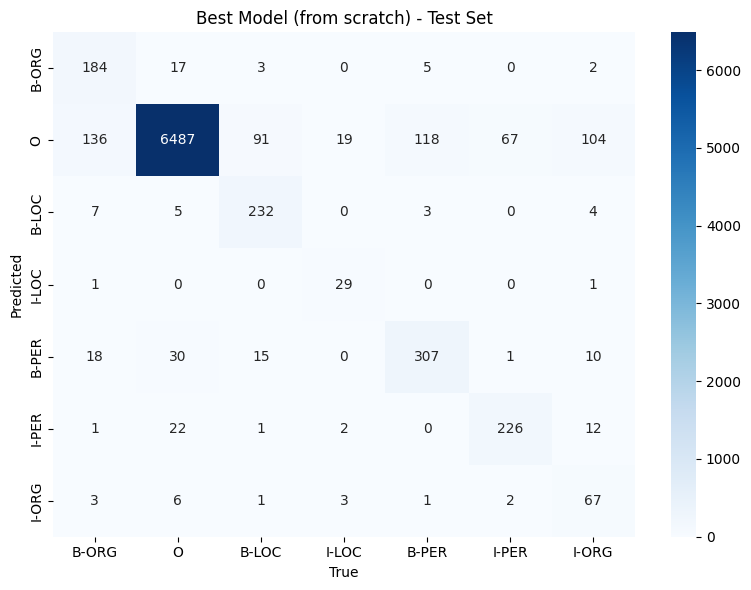

Best from-scratch model test results: {'RECALL': 0.913744995753973, 'PRECISION': 0.9102319035190564, 'F1': 0.9055552925959474, 'RECALL_WO_O': 0.6235083532219571, 'PRECISION_WO_O': 0.8570259732392912, 'F1_WO_O': 0.7128259340026966}


In [24]:
# Pick the best architecture by dev-set F1 excluding "O" (the metric that reflects
# entity quality, since "O" dominates the token distribution).
best_idx = results_dev['F1_WO_O'].astype(float).idxmax()
best_row = results_dev.loc[best_idx]
best_model_cfg = {
    'embedding_size': EMB_DIM,
    'hidden_size': int(best_row['HIDDEN_SIZE']),
    'n_layers': int(best_row['N_LAYERS']),
    'directions': int(best_row['DIRECTIONS']),
}
print("Best model config:", best_model_cfg)
# TO DO ----------------------------------------------------------------------
# Train the chosen configuration for 10 epochs total and evaluate on the test set.
th.manual_seed(SEED)
best_model = NERNet(vocab.n_words, embedding_size=EMB_DIM,
                    hidden_size=best_model_cfg['hidden_size'], output_size=vocab.n_tags,
                    n_layers=best_model_cfg['n_layers'], directions=best_model_cfg['directions'])
best_model.to(DEVICE)
train_loop(best_model, n_epochs=10, dataloader_train=dl_train, dataloader_dev=dl_dev)
best_results = evaluate(best_model, title="Best Model (from scratch) - Test Set",
                        dataloader=dl_test, vocab=vocab)
print("Best from-scratch model test results:", best_results)
# TO DO ----------------------------------------------------------------------

<br><br><br><br><br>

# Part 4 - Pretrained Embeddings



To prepare for this task, please read [this discussion](https://discuss.pytorch.org/t/can-we-use-pre-trained-word-embeddings-for-weight-initialization-in-nn-embedding/1222).

**TIP**: Ensure that the vectors are aligned with the IDs in your vocabulary. In other words, make sure that the word with ID 0 corresponds to the first vector in the GloVe matrix used to initialize `nn.Embedding`.



## Step 1: Get Data



Download the GloVe embeddings from [this link](https://nlp.stanford.edu/projects/glove/). Use the 300-dimensional vectors from `glove.6B.zip`.



In [25]:
# TO DO ----------------------------------------------------------------------
# Download GloVe 6B and extract the 300d vectors (only the file we need).
import os
if not os.path.exists('glove.6B.300d.txt'):
    !wget -q http://nlp.stanford.edu/data/glove.6B.zip
    !unzip -q -o glove.6B.zip glove.6B.300d.txt
    print("Downloaded and extracted glove.6B.300d.txt")
else:
    print("glove.6B.300d.txt already present")
# TO DO ----------------------------------------------------------------------

Downloaded and extracted glove.6B.300d.txt


## Step 2: Inject Embeddings

Then intialize the `nn.Embedding` module in your `NERNet` with these embeddings, so that you can start your training with pre-trained vectors.

In [26]:
def get_emb_matrix(filepath: str, vocab: Vocab) -> np.ndarray:
  emb_matrix = np.zeros((len(vocab.word2id), 300))
  # TO DO ----------------------------------------------------------------------
  # Words missing from GloVe get a small random vector; PAD stays at zero.
  rng = np.random.default_rng(SEED)
  emb_matrix = rng.normal(scale=0.1, size=(len(vocab.word2id), 300)).astype(np.float32)
  emb_matrix[PAD_TOKEN] = 0.0

  found = 0
  with open(filepath, encoding="utf-8") as f:
    for line in f:
      parts = line.rstrip().split(' ')
      word = parts[0]
      idx = vocab.word2id.get(word)
      if idx is not None:
        emb_matrix[idx] = np.asarray(parts[1:], dtype=np.float32)
        found += 1
  print(f"Found pretrained vectors for {found}/{len(vocab.word2id)} vocab words")
  # TO DO ----------------------------------------------------------------------
  return emb_matrix

In [27]:
def initialize_from_pretrained_emb(model: NERNet, emb_matrix: np.ndarray):
  """
  Inject the pretrained embeddings into the model.
  :param model: model instance
  :param emb_matrix: pretrained embeddings
  """
  # TO DO ----------------------------------------------------------------------
  # Row i of emb_matrix aligns with word id i, matching nn.Embedding's indexing.
  weights = th.tensor(emb_matrix, dtype=th.float32)
  with th.no_grad():
    model.embedding.weight.data.copy_(weights)
    model.embedding.weight[PAD_TOKEN].fill_(0.0)
  # TO DO ----------------------------------------------------------------------

In [28]:
# Read embeddings and inject them to a model
emb_file = 'glove.6B.300d.txt'
emb_matrix = get_emb_matrix(emb_file, vocab)
ner_glove = NERNet(input_size=vocab.n_words, embedding_size=EMB_DIM, hidden_size=500, output_size=vocab.n_tags, n_layers=1, directions=1)
initialize_from_pretrained_emb(ner_glove, emb_matrix)

Found pretrained vectors for 3737/7163 vocab words


## Step 3: Evaluate on Test Set

Same as the evaluation process before, please display:

1. Print a `RECALL-PRECISION-F1` scores in a tabulate format.
2. Display a `confusion matrix` plot: where the predicted labels are the rows, and the true labels are the columns.

Make sure to use the title for the plot, axis names, and the names of the tags on the X-axis.

The CSV will be submitted automatically along with your results.

In [29]:
results = pd.DataFrame(columns=columns)
file_name = "NER_results_glove.csv"
# TO DO ----------------------------------------------------------------------
emb_matrix = get_emb_matrix('glove.6B.300d.txt', vocab)

glove_trained = {}
glove_dev_f1wo = {}
for i, (name, cfg) in enumerate(models.items(), start=1):
  print(f"\n=== GloVe {name}: {cfg} ===")
  th.manual_seed(SEED)
  m = NERNet(vocab.n_words, embedding_size=cfg['embedding_size'], hidden_size=cfg['hidden_size'],
             output_size=vocab.n_tags, n_layers=cfg['n_layers'], directions=cfg['directions'])
  m.to(DEVICE)
  initialize_from_pretrained_emb(m, emb_matrix)
  train_loop(m, n_epochs=N_EPOCHS, dataloader_train=dl_train, dataloader_dev=dl_dev)
  dev_res = evaluate(m, title="", dataloader=dl_dev, vocab=vocab)
  test_res = evaluate(m, title="", dataloader=dl_test, vocab=vocab)
  glove_trained[name] = m
  glove_dev_f1wo[name] = dev_res['F1_WO_O']
  results.loc[len(results)] = [
      f'model_{i}', cfg['hidden_size'], cfg['n_layers'], cfg['directions'],
      test_res['RECALL'], test_res['PRECISION'], test_res['F1'],
      test_res['RECALL_WO_O'], test_res['PRECISION_WO_O'], test_res['F1_WO_O'],
  ]
results.to_csv(file_name, index=False)
# TO DO ----------------------------------------------------------------------
print(tabulate(results, headers='keys', tablefmt='psql',floatfmt=".4f"))

Found pretrained vectors for 3737/7163 vocab words

=== GloVe Model1: {'embedding_size': 300, 'hidden_size': 500, 'n_layers': 1, 'directions': 1} ===


Epochs: 100%|██████████| 5/5 [00:05<00:00,  1.12s/it]


+----------------+----------+-------------+--------+
|                |   Recall |   Precision |     F1 |
|----------------+----------+-------------+--------|
| All labels (7) |   0.8349 |      0.8087 | 0.8094 |
| Without O (6)  |   0.3506 |      0.5381 | 0.3936 |
+----------------+----------+-------------+--------+
+----------------+----------+-------------+--------+
|                |   Recall |   Precision |     F1 |
|----------------+----------+-------------+--------|
| All labels (7) |   0.8371 |      0.8190 | 0.8154 |
| Without O (6)  |   0.3574 |      0.5398 | 0.3915 |
+----------------+----------+-------------+--------+

=== GloVe Model2: {'embedding_size': 300, 'hidden_size': 500, 'n_layers': 2, 'directions': 1} ===


Epochs: 100%|██████████| 5/5 [00:09<00:00,  1.99s/it]


+----------------+----------+-------------+--------+
|                |   Recall |   Precision |     F1 |
|----------------+----------+-------------+--------|
| All labels (7) |   0.8050 |      0.7707 | 0.7844 |
| Without O (6)  |   0.3577 |      0.2939 | 0.3104 |
+----------------+----------+-------------+--------+
+----------------+----------+-------------+--------+
|                |   Recall |   Precision |     F1 |
|----------------+----------+-------------+--------|
| All labels (7) |   0.8042 |      0.7752 | 0.7866 |
| Without O (6)  |   0.3496 |      0.2717 | 0.2959 |
+----------------+----------+-------------+--------+

=== GloVe Model3: {'embedding_size': 300, 'hidden_size': 500, 'n_layers': 3, 'directions': 1} ===


...

+----------------+----------+-------------+--------+
|                |   Recall |   Precision |     F1 |
|----------------+----------+-------------+--------|
| All labels (7) |   0.8696 |      0.8539 | 0.8596 |
| Without O (6)  |   0.4994 |      0.6059 | 0.5446 |
+----------------+----------+-------------+--------+
+----------------+----------+-------------+--------+
|                |   Recall |   Precision |     F1 |
|----------------+----------+-------------+--------|
| All labels (7) |   0.8748 |      0.8646 | 0.8677 |
| Without O (6)  |   0.5167 |      0.6225 | 0.5614 |
+----------------+----------+-------------+--------+

=== GloVe Model8: {'embedding_size': 300, 'hidden_size': 800, 'n_layers': 2, 'directions': 2} ===


Epochs: 100%|██████████| 5/5 [00:55<00:00, 11.01s/it]


+----------------+----------+-------------+--------+
|                |   Recall |   Precision |     F1 |
|----------------+----------+-------------+--------|
| All labels (7) |   0.8793 |      0.8820 | 0.8779 |
| Without O (6)  |   0.6576 |      0.6175 | 0.6247 |
+----------------+----------+-------------+--------+
+----------------+----------+-------------+--------+
|                |   Recall |   Precision |     F1 |
|----------------+----------+-------------+--------|
| All labels (7) |   0.8752 |      0.8831 | 0.8771 |
| Without O (6)  |   0.6593 |      0.5886 | 0.6147 |
+----------------+----------+-------------+--------+

=== GloVe Model9: {'embedding_size': 300, 'hidden_size': 800, 'n_layers': 3, 'directions': 2} ===


Epochs: 100%|██████████| 5/5 [01:29<00:00, 17.87s/it]


+----------------+----------+-------------+--------+
|                |   Recall |   Precision |     F1 |
|----------------+----------+-------------+--------|
| All labels (7) |   0.8666 |      0.8783 | 0.8613 |
| Without O (6)  |   0.6068 |      0.6232 | 0.5634 |
+----------------+----------+-------------+--------+
+----------------+----------+-------------+--------+
|                |   Recall |   Precision |     F1 |
|----------------+----------+-------------+--------|
| All labels (7) |   0.8690 |      0.8816 | 0.8668 |
| Without O (6)  |   0.6098 |      0.6009 | 0.5638 |
+----------------+----------+-------------+--------+
+----+-----------+---------------+------------+--------------+----------+-------------+--------+---------------+------------------+-----------+
|    | N_MODEL   |   HIDDEN_SIZE |   N_LAYERS |   DIRECTIONS |   RECALL |   PRECISION |     F1 |   RECALL_WO_O |   PRECISION_WO_O |   F1_WO_O |
|----+-----------+---------------+------------+--------------+----------+---

## Step 4 - best model
Decide which model performs the best, write its configuration, train it for **10 epochs total** (5 more than the original 5), and evaluate it on the test set.

Best GloVe model config: {'embedding_size': 300, 'hidden_size': 800, 'n_layers': 2, 'directions': 2}


Epochs: 100%|██████████| 10/10 [01:50<00:00, 11.04s/it]


+----------------+----------+-------------+--------+
|                |   Recall |   Precision |     F1 |
|----------------+----------+-------------+--------|
| All labels (7) |   0.8807 |      0.9021 | 0.8871 |
| Without O (6)  |   0.7440 |      0.5987 | 0.6544 |
+----------------+----------+-------------+--------+


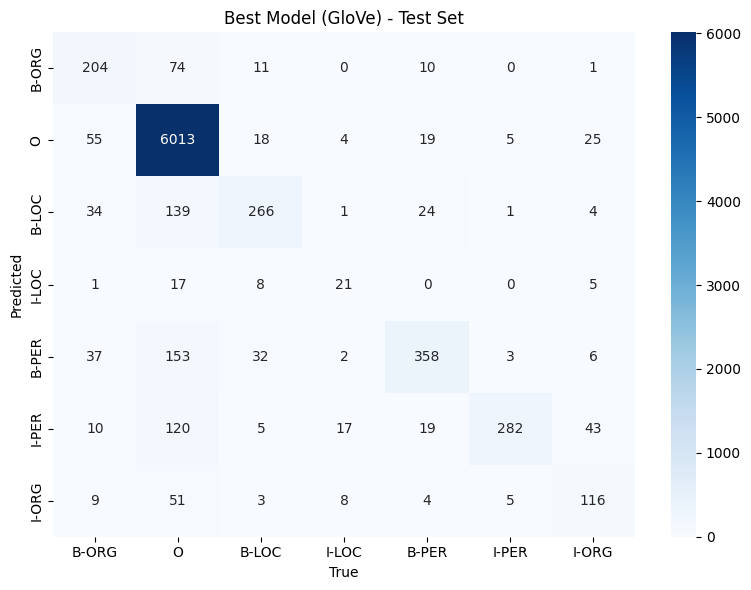

Best GloVe model test results: {'RECALL': 0.8807473007400218, 'PRECISION': 0.9020637051592523, 'F1': 0.8870906299543524, 'RECALL_WO_O': 0.7440334128878282, 'PRECISION_WO_O': 0.598744399890266, 'F1_WO_O': 0.6543800236466101}


In [30]:
# Best GloVe model chosen by dev-set F1 excluding "O".
best_name = max(glove_dev_f1wo, key=glove_dev_f1wo.get)
best_cfg = models[best_name]
best_model_glove_cfg = {
    'embedding_size': EMB_DIM,
    'hidden_size': best_cfg['hidden_size'],
    'n_layers': best_cfg['n_layers'],
    'directions': best_cfg['directions'],
}
print("Best GloVe model config:", best_model_glove_cfg)
# TO DO ----------------------------------------------------------------------
th.manual_seed(SEED)
best_glove = NERNet(vocab.n_words, embedding_size=EMB_DIM,
                    hidden_size=best_model_glove_cfg['hidden_size'], output_size=vocab.n_tags,
                    n_layers=best_model_glove_cfg['n_layers'], directions=best_model_glove_cfg['directions'])
best_glove.to(DEVICE)
initialize_from_pretrained_emb(best_glove, emb_matrix)
train_loop(best_glove, n_epochs=10, dataloader_train=dl_train, dataloader_dev=dl_dev)
best_glove_results = evaluate(best_glove, title="Best Model (GloVe) - Test Set",
                              dataloader=dl_test, vocab=vocab)
print("Best GloVe model test results:", best_glove_results)
# TO DO ----------------------------------------------------------------------

# Part 5 - Error Analysis

In this part, you'll analyze the errors made by your best model to understand its strengths and weaknesses.

## Step 1: Extract Predictions

First, let's extract predictions from your best model on the test set:

In [31]:
def get_predictions(model, dataloader, vocab, PAD_TOKEN, DEVICE):
    """
    Get predictions from the model on a dataloader.

    Returns:
        - true_tags_list: List of lists of true tag strings
        - pred_tags_list: List of lists of predicted tag strings
        - words_list: List of lists of words
    """
    import torch

    model.eval()
    true_tags_list = []
    pred_tags_list = []
    words_list = []

    with torch.no_grad():
        for batch in dataloader:
            # Dataloader yields (input_ids, labels) pairs.
            input_ids, labels = batch
            input_ids = input_ids.to(DEVICE)
            labels = labels.to(DEVICE)

            # Get model predictions.
            outputs = model(input_ids)
            _, predicted = torch.max(outputs, 2)

            # Process each sequence in the batch.
            for i in range(input_ids.size(0)):
                # Get sequence length (ignoring padding).
                seq_len = (input_ids[i] != PAD_TOKEN).sum().item()

                # Convert ids back to tag strings and words.
                true_tags = [vocab.id2tag[tag.item()] for tag in labels[i][:seq_len]]
                pred_tags = [vocab.id2tag[tag.item()] for tag in predicted[i][:seq_len]]
                words = [vocab.id2word[word.item()] for word in input_ids[i][:seq_len]]

                true_tags_list.append(true_tags)
                pred_tags_list.append(pred_tags)
                words_list.append(words)

    return true_tags_list, pred_tags_list, words_list

## Step 2: Helper Functions

Before writing the error analysis, implement two utility functions that you will need.

### 2a: `get_entities_simple(tags)`

**Goal:** Extract named entities from a single IOB tag sequence.

**Input:** A list of IOB tag strings, e.g. `['O', 'B-PER', 'I-PER', 'O', 'B-LOC', 'O']`

**Output:** A list of tuples `(start_idx, end_idx, entity_type)` where:
- `start_idx` is the index of the `B-` tag
- `end_idx` is the index of the last `I-` tag of that entity (or same as `start_idx` if the entity is a single token)
- `entity_type` is the string after `B-`/`I-` (e.g. `"PER"`, `"LOC"`, `"ORG"`)

**Logic:** Walk through the tag list. When you see a `B-X` tag, start a new entity. Keep extending it while the next tags are `I-X` (same type). When the entity ends, append the tuple. Ignore `O` tags.

**Example:**
```python
tags = ['O', 'B-PER', 'I-PER', 'O', 'B-LOC', 'O']
get_entities_simple(tags)
# Returns: [(1, 2, 'PER'), (4, 4, 'LOC')]
```

### 2b: `has_overlap(start1, end1, start2, end2)`

**Goal:** Check if two index spans share at least one position.

**Input:** Four integers — start and end indices of two spans.

**Output:** `True` if they overlap, `False` otherwise.

**Example:**
```python
has_overlap(1, 3, 2, 5)  # True  (overlap at indices 2, 3)
has_overlap(1, 2, 4, 5)  # False (no shared indices)
```

In [32]:
def get_entities_simple(tags):
    """
    Extract entities from a sequence of IOB tags.

    Args:
        tags: List of tag strings, e.g. ['O', 'B-PER', 'I-PER', 'O']

    Returns:
        List of (start_idx, end_idx, entity_type) tuples.
        Example: [(1, 2, 'PER')]
    """
    entities = []
    i = 0
    n = len(tags)
    while i < n:
        tag = tags[i]
        if tag.startswith("B-"):
            etype = tag[2:]
            start = i
            end = i
            j = i + 1
            # Extend while the following tags are I- of the same type.
            while j < n and tags[j] == "I-" + etype:
                end = j
                j += 1
            entities.append((start, end, etype))
            i = j
        else:
            i += 1
    return entities

def has_overlap(start1, end1, start2, end2):
    """
    Check if two spans overlap (share at least one index).

    Args:
        start1, end1: start and end indices of the first span
        start2, end2: start and end indices of the second span

    Returns:
        True if the spans overlap, False otherwise.
    """
    return start1 <= end2 and start2 <= end1

## Step 3: Implement Entity-Level Error Analysis

**Goal:** Compare the true and predicted entity spans (extracted using `get_entities_simple`) to count and categorize errors at the **entity level**.

**Function signature:**
```python
def simple_analyze_errors(true_tags, pred_tags, words) -> dict
```

**Inputs:**
- `true_tags`: list of lists of tag strings (one inner list per sentence)
- `pred_tags`: list of lists of tag strings (one inner list per sentence)
- `words`: list of lists of word strings (one inner list per sentence)

**What to do — for each sentence:**
1. Extract true entities using `get_entities_simple(true_tags[i])`
2. Extract predicted entities using `get_entities_simple(pred_tags[i])`
3. Classify each **true entity** into one of these categories:
   - **Correct:** A predicted entity has the exact same `(start, end, type)`.
   - **Type error:** A predicted entity has the same `(start, end)` but a **different** type (e.g., true=`PER`, predicted=`ORG`).
   - **Boundary error:** A predicted entity **overlaps** (use `has_overlap`) and has the **same type**, but the start/end indices differ.
   - **Missed:** No predicted entity overlaps with this true entity at all.
4. Also count **Spurious** predictions: predicted entities that do **not** overlap with any true entity.

**Return value — a dictionary:**
```python
{
    'total_entities': int,       # total number of true entities across all sentences
    'correct_entities': int,     # number of exact matches
    'accuracy': float,           # correct_entities / total_entities
    'error_counts': {
        'type_error': int,
        'boundary_error': int,
        'missed': int,
        'spurious': int
    },
    'error_examples': {          # store up to 3 examples per category
        'type_error': [(words, true_entity, pred_entity), ...],
        'boundary_error': [(words, true_entity, pred_entity), ...],
        'missed': [(words, true_entity), ...],
        'spurious': [(words, pred_entity), ...]
    }
}
```

**Example walkthrough:**
```python
true_tags = [['O', 'B-PER', 'I-PER', 'O', 'B-LOC', 'I-LOC', 'O']]
pred_tags = [['O', 'B-PER', 'O',     'O', 'B-ORG', 'I-ORG', 'O']]
words     = [['The', 'John', 'Smith', 'visited', 'New', 'York', 'yesterday']]

# True entities:  [(1,2,'PER'), (4,5,'LOC')]
# Pred entities:  [(1,1,'PER'), (4,5,'ORG')]
#
# (1,2,'PER') vs (1,1,'PER') → boundary_error (same type PER, overlapping spans, but end differs)
# (4,5,'LOC') vs (4,5,'ORG') → type_error (same span, different type)
```

In [33]:
def simple_analyze_errors(true_tags, pred_tags, words):
    """
    Analyze errors in NER predictions at the entity level.

    Args:
        true_tags: List of lists of true tag strings (one list per sentence)
        pred_tags: List of lists of predicted tag strings (one list per sentence)
        words: List of lists of word strings (one list per sentence)

    Returns:
        dict with keys: total_entities, correct_entities, accuracy,
                        error_counts (dict), error_examples (dict), errors_by_type (dict)
    """
    error_counts = {'type_error': 0, 'boundary_error': 0, 'missed': 0, 'spurious': 0}
    error_examples = {'type_error': [], 'boundary_error': [], 'missed': [], 'spurious': []}
    errors_by_type = {'PER': 0, 'LOC': 0, 'ORG': 0}

    total_entities = 0
    correct_entities = 0

    for true_seq, pred_seq, sent in zip(true_tags, pred_tags, words):
        true_entities = get_entities_simple(true_seq)
        pred_entities = get_entities_simple(pred_seq)

        # Classify each true entity.
        for (ts, te, ttype) in true_entities:
            total_entities += 1
            category, matched = None, None

            # 1. Exact match -> correct
            for (ps, pe, ptype) in pred_entities:
                if ps == ts and pe == te and ptype == ttype:
                    category, matched = 'correct', (ps, pe, ptype)
                    break
            # 2. Same span, different type -> type error
            if category is None:
                for (ps, pe, ptype) in pred_entities:
                    if ps == ts and pe == te and ptype != ttype:
                        category, matched = 'type_error', (ps, pe, ptype)
                        break
            # 3. Same type, overlapping but different boundaries -> boundary error
            if category is None:
                for (ps, pe, ptype) in pred_entities:
                    if ptype == ttype and has_overlap(ts, te, ps, pe) and (ps != ts or pe != te):
                        category, matched = 'boundary_error', (ps, pe, ptype)
                        break
            # 4. No overlapping prediction -> missed
            if category is None:
                category = 'missed'

            if category == 'correct':
                correct_entities += 1
            else:
                error_counts[category] += 1
                if ttype in errors_by_type:
                    errors_by_type[ttype] += 1
                if category == 'missed':
                    if len(error_examples['missed']) < 3:
                        error_examples['missed'].append((sent, (ts, te, ttype)))
                else:
                    if len(error_examples[category]) < 3:
                        error_examples[category].append((sent, (ts, te, ttype), matched))

        # Spurious: predicted entities that overlap no true entity at all.
        for (ps, pe, ptype) in pred_entities:
            overlaps_any = any(has_overlap(ps, pe, ts, te) for (ts, te, tt) in true_entities)
            if not overlaps_any:
                error_counts['spurious'] += 1
                if ptype in errors_by_type:
                    errors_by_type[ptype] += 1
                if len(error_examples['spurious']) < 3:
                    error_examples['spurious'].append((sent, (ps, pe, ptype)))

    return {
        'total_entities': total_entities,
        'correct_entities': correct_entities,
        'accuracy': correct_entities / total_entities if total_entities else 0.0,
        'error_counts': error_counts,
        'error_examples': error_examples,
        'errors_by_type': errors_by_type,
    }

## Step 4: Display the Error Analysis

**Goal:** Print a readable summary of the error analysis dictionary returned by `simple_analyze_errors`.

**Function signature:**
```python
def print_error_analysis(analysis):
```

**Input:** The dictionary returned by `simple_analyze_errors`.

**What to print — three sections:**

**Section 1 — Overall statistics** (use `tabulate` or simple print statements):
```
Total entities:     500
Correct:            420 (84.0%)
Type errors:         15
Boundary errors:     25
Missed:              40
Spurious:            30
```

**Section 2 — Examples for each error type.** Print up to 3 examples per category, showing the sentence words and the relevant entity span. Format each example like:
```
[Type Error] "... New York ..." — true: LOC(4,5), predicted: ORG(4,5)
[Missed]     "... John Smith ..." — true: PER(1,2), predicted: (none)
```

**Section 3 — Which entity type (PER / LOC / ORG) has the most errors?** Print one line stating the answer.

In [34]:
def print_error_analysis(analysis):
    """
    Print a readable summary of the error analysis results.
    """
    ec = analysis['error_counts']
    total = analysis['total_entities']
    correct = analysis['correct_entities']
    acc = analysis['accuracy']

    # Section 1: overall statistics
    print("=" * 60)
    print("ENTITY-LEVEL ERROR ANALYSIS")
    print("=" * 60)
    stats = [
        ["Total entities", total],
        ["Correct", f"{correct} ({acc * 100:.1f}%)"],
        ["Type errors", ec['type_error']],
        ["Boundary errors", ec['boundary_error']],
        ["Missed", ec['missed']],
        ["Spurious", ec['spurious']],
    ]
    print(tabulate(stats, tablefmt='plain'))
    print()

    # Section 2: examples
    ex = analysis['error_examples']

    def span_str(e):
        return f"{e[2]}({e[0]},{e[1]})"

    def ctx(sent, s, e, pad=2):
        lo, hi = max(0, s - pad), min(len(sent), e + 1 + pad)
        return " ".join(sent[lo:hi])

    print("--- Examples (up to 3 per category) ---")
    for sent, te, pe in ex['type_error']:
        print(f'[Type Error] "... {ctx(sent, te[0], te[1])} ..." - true: {span_str(te)}, predicted: {span_str(pe)}')
    for sent, te, pe in ex['boundary_error']:
        print(f'[Boundary]   "... {ctx(sent, te[0], te[1])} ..." - true: {span_str(te)}, predicted: {span_str(pe)}')
    for sent, te in ex['missed']:
        print(f'[Missed]     "... {ctx(sent, te[0], te[1])} ..." - true: {span_str(te)}, predicted: (none)')
    for sent, pe in ex['spurious']:
        print(f'[Spurious]   "... {ctx(sent, pe[0], pe[1])} ..." - true: (none), predicted: {span_str(pe)}')
    print()

    # Section 3: which entity type has the most errors
    ebt = analysis.get('errors_by_type', {})
    if ebt and any(ebt.values()):
        worst = max(ebt, key=ebt.get)
        print(f"Entity type with the most errors: {worst} ({ebt[worst]} errors)  |  breakdown: {dict(ebt)}")
    else:
        print("Entity type with the most errors: none (no errors found)")

## Step 5: Improvement Suggestions

**Goal:** Based on the output of your error analysis, write **3 concrete improvement suggestions** below (no code required — just text).

**Requirements:**
- Write 2–4 sentences per suggestion.
- Each suggestion **must reference a specific finding** from your error analysis (e.g., "42% of errors are boundary errors on PER entities, which suggests...").
- Choose 3 of the following directions:
  1. Using a **CRF layer** on top of the LSTM to enforce valid IOB transitions
  2. Using **subword or character-level embeddings** to handle rare / OOV entity words
  3. Adding more **training data or data augmentation** for the weakest entity type
  4. Using **contextual embeddings** (e.g., BERT) instead of static word embeddings
  5. **Post-processing rules** to fix common boundary errors

**Expected output:** A markdown cell (below) with three numbered paragraphs.

In [35]:
# Use the best from-scratch model (Part 3, Step 4) for error analysis if available.
analysis_model = best_model if 'best_model' in globals() else model

# Extract predictions from the model on the test set.
true_tags_list, pred_tags_list, words_list = get_predictions(analysis_model, dl_test, vocab, PAD_TOKEN, DEVICE)

# Run the error analysis
analysis = simple_analyze_errors(true_tags_list, pred_tags_list, words_list)

# Display the results
print_error_analysis(analysis)

ENTITY-LEVEL ERROR ANALYSIS
Total entities   1127
Correct          680 (60.3%)
Type errors      40
Boundary errors  46
Missed           361
Spurious         50

--- Examples (up to 3 per category) ---
[Type Error] "... __unk__ , __unk__ ..." - true: LOC(0,0), predicted: PER(0,0)
[Type Error] "... Abbaye , Europe 's top ..." - true: LOC(19,19), predicted: PER(19,19)
[Type Error] "... __unk__ v Legia Warsaw ( Poland ..." - true: ORG(2,3), predicted: PER(2,3)
[Boundary]   "... __unk__ 's News Corp Ltd reported lower ..." - true: ORG(5,7), predicted: ORG(5,6)
[Boundary]   "... firm , Kingston __unk__ Co . ..." - true: ORG(29,31), predicted: ORG(29,29)
[Boundary]   "... Natural Law Party says it ..." - true: ORG(0,2), predicted: ORG(0,1)
[Missed]     "... __unk__ __unk__ is also ..." - true: PER(0,1), predicted: (none)
[Missed]     "... __unk__ , __unk__ 1996-08-21 ..." - true: LOC(2,2), predicted: (none)
[Missed]     "... effect __unk__ SunGard 's financial ..." - true: ORG(11,11), predict

### Your Improvement Suggestions

My error analysis on the best from-scratch model (BiLSTM, hidden 800, 3 layers, bidirectional) found **1127** true entities in the test set, of which only **680 (60.3%)** were exactly correct. The error breakdown was **361 missed**, **46 boundary**, **40 type**, and **50 spurious**; by entity type, **ORG had the most errors (199), then PER (179) and LOC (119)**.

1. **Subword / character-level embeddings.** By far the dominant error is *missed* entities — **361 of the 447 true-entity errors (≈81%)** — and almost every missed example is an out-of-vocabulary token printed as `__unk__` (e.g. true `PER(0,1)` = "`__unk__ __unk__`", true `ORG(11,11)` = "SunGard"). This is expected given the **1368 OOV tokens in the test set**, and that GloVe covered only **3737/7163 (52%)** of the vocabulary — every other word collapses to a single `__unk__` vector with no signal. A character-CNN/BiLSTM that builds word vectors from characters would capture capitalization and morphology (suffixes like *-Corp*, *-Ltd*) and give the model real features for names it has never seen, directly attacking the missed-entity problem.

2. **CRF layer on top of the LSTM.** All **46 boundary errors** in the examples are multi-token spans whose prediction is truncated — e.g. true `ORG(5,7)` ("News Corp Ltd") predicted as `ORG(5,6)`, and true `ORG(0,2)` ("Natural Law Party") predicted as `ORG(0,1)`. A per-token softmax labels each position independently, so it easily ends an `I-ORG` run too early; a CRF scores the whole tag sequence jointly and learns transition preferences between tags, which is exactly the mechanism needed to keep long entity spans intact and cut these boundary truncations.

3. **More data / augmentation for the weakest entity type (ORG).** The per-type breakdown shows **ORG is the hardest class with 199 errors** (vs. 179 for PER and 119 for LOC), and the type errors confirm ORGs are frequently mislabeled as PER (e.g. true `ORG(2,3)` predicted `PER(2,3)`). Oversampling training sentences that contain organizations, or augmenting via gazetteer-based entity swapping for ORG names, would expose the model to more of the long, varied organization spans it currently confuses with people — reducing both its type errors and its missed ORGs.

# Testing

Before running the tests:
1. Create a **sharing link** to your notebook with **editor access**.
2. Paste it in the `NOTEBOOK_LINK` variable below.

Then run the test cells to create the `results.json` file.

In [41]:
NOTEBOOK_LINK = "https://colab.research.google.com/drive/1Dl8k3PCDEMdEFWdcP01AdBVe25RK0p6v?usp=sharing"

In [45]:
########################################
# Tests

import json

def test_link():
    return {
        'link': NOTEBOOK_LINK
    }

train_ds = read_data("data/train.txt")
dev_ds = read_data("data/dev.txt")
test_ds = read_data("data/test.txt")
def test_read_data():
    result = {
        'lengths': (len(train_ds), len(dev_ds), len(test_ds)),
    }
    return result

vocab = Vocab(train_ds)
def test_vocab():
    sent = vocab.index_words(["I", "am", "Spongebob"])
    return {
        'length': vocab.n_words,
        'tag2id_length': len(vocab.tag2id),
        "Spongebob": sent[2]
    }

train_sequences = prepare_data(train_ds, vocab)
dev_sequences = prepare_data(dev_ds, vocab)
test_sequences = prepare_data(test_ds, vocab)

def test_count_oov():
    return {
        'dev_oov': count_oov(dev_sequences),
        'test_oov': count_oov(test_sequences)
    }

BATCH_SIZE = 16
dl_train = prepare_data_loader(train_sequences, batch_size=BATCH_SIZE)
dl_dev = prepare_data_loader(dev_sequences, batch_size=BATCH_SIZE, train=False)
dl_test = prepare_data_loader(test_sequences, batch_size=BATCH_SIZE, train=False)

def test_prepare_data_loader():
    return {
        'lengths': (len(dl_train), len(dl_dev), len(dl_test))
    }


def test_NERNet():
    # Extract best model configuration
    hidden_size = best_model_cfg['hidden_size']
    n_layers = best_model_cfg['n_layers']
    directions = best_model_cfg['directions']


    # Create model
    best_model = NERNet(vocab.n_words, embedding_size=300, hidden_size=hidden_size, output_size=vocab.n_tags, n_layers=n_layers, directions=directions)
    best_model.to(DEVICE)

    # Train model and evaluate
    _ = train_loop(best_model, n_epochs=10, dataloader_train=dl_train, dataloader_dev=dl_dev)
    results = evaluate(best_model, title="", dataloader=dl_test, vocab=vocab)

    return {
        'f1': results['F1'],
        'f1_wo_o': results['F1_WO_O'],
    }

def test_glove():
    # Get embeddings
    emb_file = 'glove.6B.300d.txt'
    emb_matrix = get_emb_matrix(emb_file, vocab)

    # Extract best model configuration
    hidden_size = best_model_glove_cfg['hidden_size']
    n_layers = best_model_glove_cfg['n_layers']
    directions = best_model_glove_cfg['directions']

    # Create model
    best_model = NERNet(vocab.n_words, embedding_size=300, hidden_size=hidden_size, output_size=vocab.n_tags, n_layers=n_layers, directions=directions)
    best_model.to(DEVICE)
    initialize_from_pretrained_emb(best_model, emb_matrix)

    # Train model and evaluate
    _ = train_loop(best_model, n_epochs=10, dataloader_train=dl_train, dataloader_dev=dl_dev)
    results = evaluate(best_model, title="", dataloader=dl_test, vocab=vocab)

    return {
        'f1': results['F1'],
        'f1_wo_o': results['F1_WO_O'],
    }

TESTS = [
    test_link,
    test_read_data,
    test_vocab,
    test_count_oov,
    test_prepare_data_loader,
    test_NERNet,
    test_glove
]

# Run tests and save results
res = {}
for test in TESTS:
    try:
        cur_res = test()
        res.update({test.__name__: cur_res})
    except Exception as e:
        import traceback
        res.update({test.__name__: repr(e) + "\n" + traceback.format_exc()})

with open('results.json', 'w') as f:
    json.dump(res, f, indent=2)

########################################

Epochs: 100%|██████████| 10/10 [02:59<00:00, 17.94s/it]


+----------------+----------+-------------+--------+
|                |   Recall |   Precision |     F1 |
|----------------+----------+-------------+--------|
| All labels (7) |   0.9136 |      0.9119 | 0.9061 |
| Without O (6)  |   0.6438 |      0.8336 | 0.7086 |
+----------------+----------+-------------+--------+
Found pretrained vectors for 3737/7163 vocab words


Epochs: 100%|██████████| 10/10 [01:50<00:00, 11.07s/it]


+----------------+----------+-------------+--------+
|                |   Recall |   Precision |     F1 |
|----------------+----------+-------------+--------|
| All labels (7) |   0.8953 |      0.9059 | 0.8986 |
| Without O (6)  |   0.7416 |      0.6451 | 0.6851 |
+----------------+----------+-------------+--------+


---

# 📤 Submit Your Assignment to GitHub

## Step 1: Authentication Setup (One-Time)

Before you can submit, you need to set up GitHub authentication.

### Creating a GitHub Personal Access Token:

1. **Go to GitHub Token Settings**: [https://github.com/settings/tokens](https://github.com/settings/tokens)

2. **Click "Generate new token (classic)"**

3. **Configure your token**:
   - **Note**: "NLP Course Assignments" (or any name you like)
   - **Expiration**: 90 days (or custom)
   - **Select scopes**: Check **`repo`** (full control of private repositories)

4. **Click "Generate token"**

5. **IMPORTANT**: Copy the token immediately and save it somewhere safe!
   - Like Colab Secrets (see picture)
   - You won't be able to see it again
   - You can reuse this token for all assignments
   - Don't share it with anyone

### Run the authentication cell below

You only need to do this **once per Colab session**. If you restart the runtime, you'll need to re-run the authentication cell.

---

In [38]:
"""
GitHub Authentication Setup
Run this cell ONCE to set up your GitHub credentials
"""

import os
from getpass import getpass

def setup_github_auth():
    """Set up GitHub credentials - run once per Colab session"""
    global GITHUB_USERNAME, GITHUB_TOKEN

    print("🔐 GitHub Authentication Setup")
    print("=" * 60)

    GITHUB_USERNAME = input("GitHub username: ")
    GITHUB_TOKEN = getpass("GitHub Personal Access Token (hidden): ")

    print("\n✅ Credentials saved for this session!")
    print("You can now run the submission cell below.")
    print("\n💡 Tip: Your credentials are only stored in this runtime.")
    print("If you restart the runtime, you'll need to run this cell again.")

# Run the setup
setup_github_auth()

🔐 GitHub Authentication Setup
GitHub username: aviv-barel
GitHub Personal Access Token (hidden): ··········

✅ Credentials saved for this session!
You can now run the submission cell below.

💡 Tip: Your credentials are only stored in this runtime.
If you restart the runtime, you'll need to run this cell again.


---

## Step 2: Submit Your Results

Once you've:
- ✅ Completed all the code cells above
- ✅ Run all the test cells
- ✅ Generated `results.json`
- ✅ Run the authentication cell

You can now submit your assignment by running the cell below!

### What you'll need:
- Your **GitHub Classroom repository URL**
  - You received this when you accepted the assignment
  - Format: `https://github.com/NLP-Reichman/2026-assignment-2-team-name`
- (Optional) A custom commit message

### After submission:
- Check your repository to see `results.json` has been uploaded
- Visit the **Actions** tab to see your autograding results
- Results typically appear within 1-2 minutes

---

In [50]:
"""
Submit Assignment to GitHub
Run this cell to push your results.json to GitHub
"""

import os
import subprocess
import json

def check_credentials():
    """Check if credentials are set"""
    try:
        _ = GITHUB_USERNAME
        _ = GITHUB_TOKEN
        return True
    except NameError:
        print("\u274c GitHub credentials not found!")
        print("Please run the authentication cell above first.")
        return False


def check_results_file():
    """Check if results.json exists"""
    if not os.path.exists('results.json'):
        print("\u274c results.json not found!")
        print("\nPlease run all the test cells above to generate results.json")
        return False

    # Display test summary
    try:
        with open('results.json', 'r') as f:
            results = json.load(f)

        print("\U0001f4ca Test Results Found:")
        print("-" * 60)
        for test_name in results.keys():
            print(f"  \u2713 {test_name}")
        print("-" * 60)
        return True
    except Exception as e:
        print(f"\u26a0\ufe0f  Warning: Could not read results.json: {e}")
        return True  # Still allow submission


def submit_to_github(repo_url, commit_message=None):
    """Submit results.json to GitHub repository"""

    if commit_message is None:
        commit_message = "Submit assignment results from Colab"

    print("\n\U0001f680 Submitting to GitHub...")
    print("=" * 60)

    # Create temporary directory
    temp_dir = '/content/github_submission'
    if os.path.exists(temp_dir):
        subprocess.run(['rm', '-rf', temp_dir], check=True, capture_output=True)

    os.makedirs(temp_dir, exist_ok=True)
    os.chdir(temp_dir)

    try:
        # Configure git
        subprocess.run(['git', 'config', '--global', 'user.email',
                       f'{GITHUB_USERNAME}@users.noreply.github.com'],
                      check=True, capture_output=True)
        subprocess.run(['git', 'config', '--global', 'user.name',
                       GITHUB_USERNAME],
                      check=True, capture_output=True)

        # Clone repository with authentication
        auth_url = repo_url.replace('https://', f'https://{GITHUB_USERNAME}:{GITHUB_TOKEN}@')

        print("\U0001f4e5 Cloning repository...")
        result = subprocess.run(['git', 'clone', auth_url, 'repo'],
                              capture_output=True, text=True)

        if result.returncode != 0:
            print(f"\u274c Error cloning repository:")
            print(result.stderr)
            print("\n\U0001f4a1 Troubleshooting:")
            print("  - Check that your repository URL is correct")
            print("  - Verify your token has 'repo' scope")
            print("  - Make sure you've accepted the assignment")
            return False

        # Change to repo directory
        os.chdir('repo')

        # Copy results.json
        print("\U0001f4dd Copying results.json...")
        subprocess.run(['cp', '/content/results.json', 'results.json'],
                      check=True, capture_output=True)

        # Copy CSV result files if they exist
        for csv_file in ['NER_results.csv', 'NER_results_glove.csv']:
            csv_path = f'/content/{csv_file}'
            if os.path.exists(csv_path):
                print(f"\U0001f4dd Copying {csv_file}...")
                subprocess.run(['cp', csv_path, csv_file],
                              check=True, capture_output=True)

        # Check for changes
        status = subprocess.run(['git', 'status', '--porcelain'],
                              capture_output=True, text=True)

        if not status.stdout.strip():
            print("\n\u2139\ufe0f  No changes detected - results.json is unchanged")
            print("\u2705 Your repository is already up to date!")
            return True

        # Commit and push
        print(f"\U0001f4ac Commit message: '{commit_message}'")
        print("\U0001f4e4 Pushing to GitHub...")

        subprocess.run(['git', 'add', 'results.json',
                        'NER_results.csv', 'NER_results_glove.csv'],
                      check=True, capture_output=True)
        subprocess.run(['git', 'commit', '-m', commit_message],
                      check=True, capture_output=True)
        subprocess.run(['git', 'push'],
                      check=True, capture_output=True)

        print("\n" + "=" * 60)
        print("\u2705 SUCCESS! Assignment submitted!")
        print("=" * 60)
        print(f"\n\U0001f4ca Repository: {repo_url}")
        print(f"\U0001f4ca Autograding: {repo_url.replace('.git', '')}/actions")
        print("\n\U0001f4a1 Your grade will appear in the Actions tab in ~1 minute")

        return True

    except subprocess.CalledProcessError as e:
        print(f"\n\u274c Git error occurred")
        if hasattr(e, 'stderr') and e.stderr:
            print(f"Details: {e.stderr}")
        return False
    except Exception as e:
        print(f"\n\u274c Unexpected error: {e}")
        return False
    finally:
        # Return to /content
        os.chdir('/content')


def main():
    """Main submission workflow"""
    print("=" * 60)
    print("\U0001f4e4 Assignment Submission")
    print("=" * 60)

    # Check credentials
    if not check_credentials():
        return

    # Check results file
    if not check_results_file():
        return

    # Get repository URL
    print("\n\U0001f4cd Enter your GitHub Classroom repository URL")
    print("Example: https://github.com/NLP-Reichman/2026-assignment-2-username")
    repo_url = input("\nRepository URL: ").strip()

    # Validate URL
    if not repo_url.startswith('https://github.com/'):
        print("\u274c Invalid URL - must start with https://github.com/")
        return

    # Get commit message (optional)
    print("\n\U0001f4ac Commit Message (optional)")
    print("Press Enter for default message, or type your own:")
    commit_msg = input("Message: ").strip()

    if not commit_msg:
        commit_msg = "Submit assignment results from Colab"

    # Confirm submission
    print("\n" + "=" * 60)
    print("Ready to submit:")
    print(f"  Repository: {repo_url}")
    print(f"  File: results.json")
    print(f"  Message: {commit_msg}")
    print("=" * 60)

    confirm = input("\nProceed? (yes/no): ").strip().lower()

    if confirm in ['yes', 'y']:
        success = submit_to_github(repo_url, commit_msg)
        if success:
            print("\n\U0001f389 All done!")
    else:
        print("\n\u274c Submission cancelled")


# Run submission
main()

📤 Assignment Submission
📊 Test Results Found:
------------------------------------------------------------
  ✓ test_link
  ✓ test_read_data
  ✓ test_vocab
  ✓ test_count_oov
  ✓ test_prepare_data_loader
  ✓ test_NERNet
  ✓ test_glove
------------------------------------------------------------

📍 Enter your GitHub Classroom repository URL
Example: https://github.com/NLP-Reichman/2026-assignment-2-username

Repository URL: https://github.com/NLP-Reichman/assignment-2-ner-aviv-s-team

💬 Commit Message (optional)
Press Enter for default message, or type your own:
Message: 50

Ready to submit:
  Repository: https://github.com/NLP-Reichman/assignment-2-ner-aviv-s-team
  File: results.json
  Message: 50

Proceed? (yes/no): yes

🚀 Submitting to GitHub...
📥 Cloning repository...
📝 Copying results.json...
📝 Copying NER_results.csv...
📝 Copying NER_results_glove.csv...
💬 Commit message: '50'
📤 Pushing to GitHub...

✅ SUCCESS! Assignment submitted!

📊 Repository: https://github.com/NLP-Reichman/a